# **Imports and load data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 30)

df = pd.read_csv("../../ml/data/synthetic/properties_raw.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (50000, 23)

Columns:
['id', 'city', 'neighbourhood', 'country', 'currency', 'property_type', 'bedrooms', 'bathrooms', 'floor_area_sqm', 'furnishing', 'price', 'price_period', 'latitude', 'longitude', 'distance_to_cbd_km', 'infrastructure_score', 'transit_access_score', 'amenity_count', 'listing_month', 'account_age_days', 'listing_count', 'tier', 'is_fraud']

Dtypes:
id                        int64
city                     object
neighbourhood            object
country                  object
currency                 object
property_type            object
bedrooms                  int64
bathrooms                 int64
floor_area_sqm          float64
furnishing               object
price                   float64
price_period             object
latitude                float64
longitude               float64
distance_to_cbd_km      float64
infrastructure_score    float64
transit_access_score    float64
amenity_count             int64
listing_month             int64
account_age_da

 # **Basic stats**

In [2]:
print("=== BASIC STATISTICS ===")
print(f"Total records:      {len(df):,}")
print(f"Clean records:      {(df.is_fraud==0).sum():,}")
print(f"Fraud records:      {(df.is_fraud==1).sum():,}")
print(f"Fraud rate:         {df.is_fraud.mean()*100:.1f}%")
print(f"\nCities:\n{df.city.value_counts()}")
print(f"\nProperty types:\n{df.property_type.value_counts()}")
print(f"\nPrice periods:\n{df.price_period.value_counts()}")
print(f"\nFurnishing:\n{df.furnishing.value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

=== BASIC STATISTICS ===
Total records:      50,000
Clean records:      47,500
Fraud records:      2,500
Fraud rate:         5.0%

Cities:
city
Nairobi          14933
Lagos            10050
Dar es Salaam     6583
Accra             6398
Mombasa           6100
Kampala           5936
Name: count, dtype: int64

Property types:
property_type
apartment     19003
house         13890
bedsitter      8127
land           4952
commercial     4028
Name: count, dtype: int64

Price periods:
price_period
monthly    29336
once       14009
yearly      6655
Name: count, dtype: int64

Furnishing:
furnishing
unfurnished       25396
semi_furnished    14509
furnished         10095
Name: count, dtype: int64

Missing values:
id                      0
city                    0
neighbourhood           0
country                 0
currency                0
property_type           0
bedrooms                0
bathrooms               0
floor_area_sqm          0
furnishing              0
price                   0
pric

# **Price stats per city**

In [3]:
print("=== PRICE STATISTICS PER CITY ===")
price_stats = df[df.is_fraud==0].groupby(["city","currency"])["price"].agg([
    "count","mean","median","std","min","max"
]).round(0)
print(price_stats.to_string())

=== PRICE STATISTICS PER CITY ===
                        count           mean       median            std        min              max
city          currency                                                                              
Accra         GHS        6079     380,241.00    10,000.00   1,026,274.00   1,000.00    10,356,400.00
Dar es Salaam TZS        6244  89,878,262.00 2,512,250.00 249,843,570.00 110,300.00 3,006,401,300.00
Kampala       UGX        5633 153,185,335.00 3,907,500.00 400,526,435.00 135,000.00 5,895,875,300.00
Lagos         NGN        9563  24,892,489.00   557,200.00  66,055,292.00  16,900.00   857,775,900.00
Mombasa       KES        5802   2,962,095.00    69,050.00   7,820,533.00   2,400.00    87,470,900.00
Nairobi       KES       14179   4,524,482.00   104,900.00  12,406,375.00   3,600.00   173,424,800.00


# **Price distribution plots**

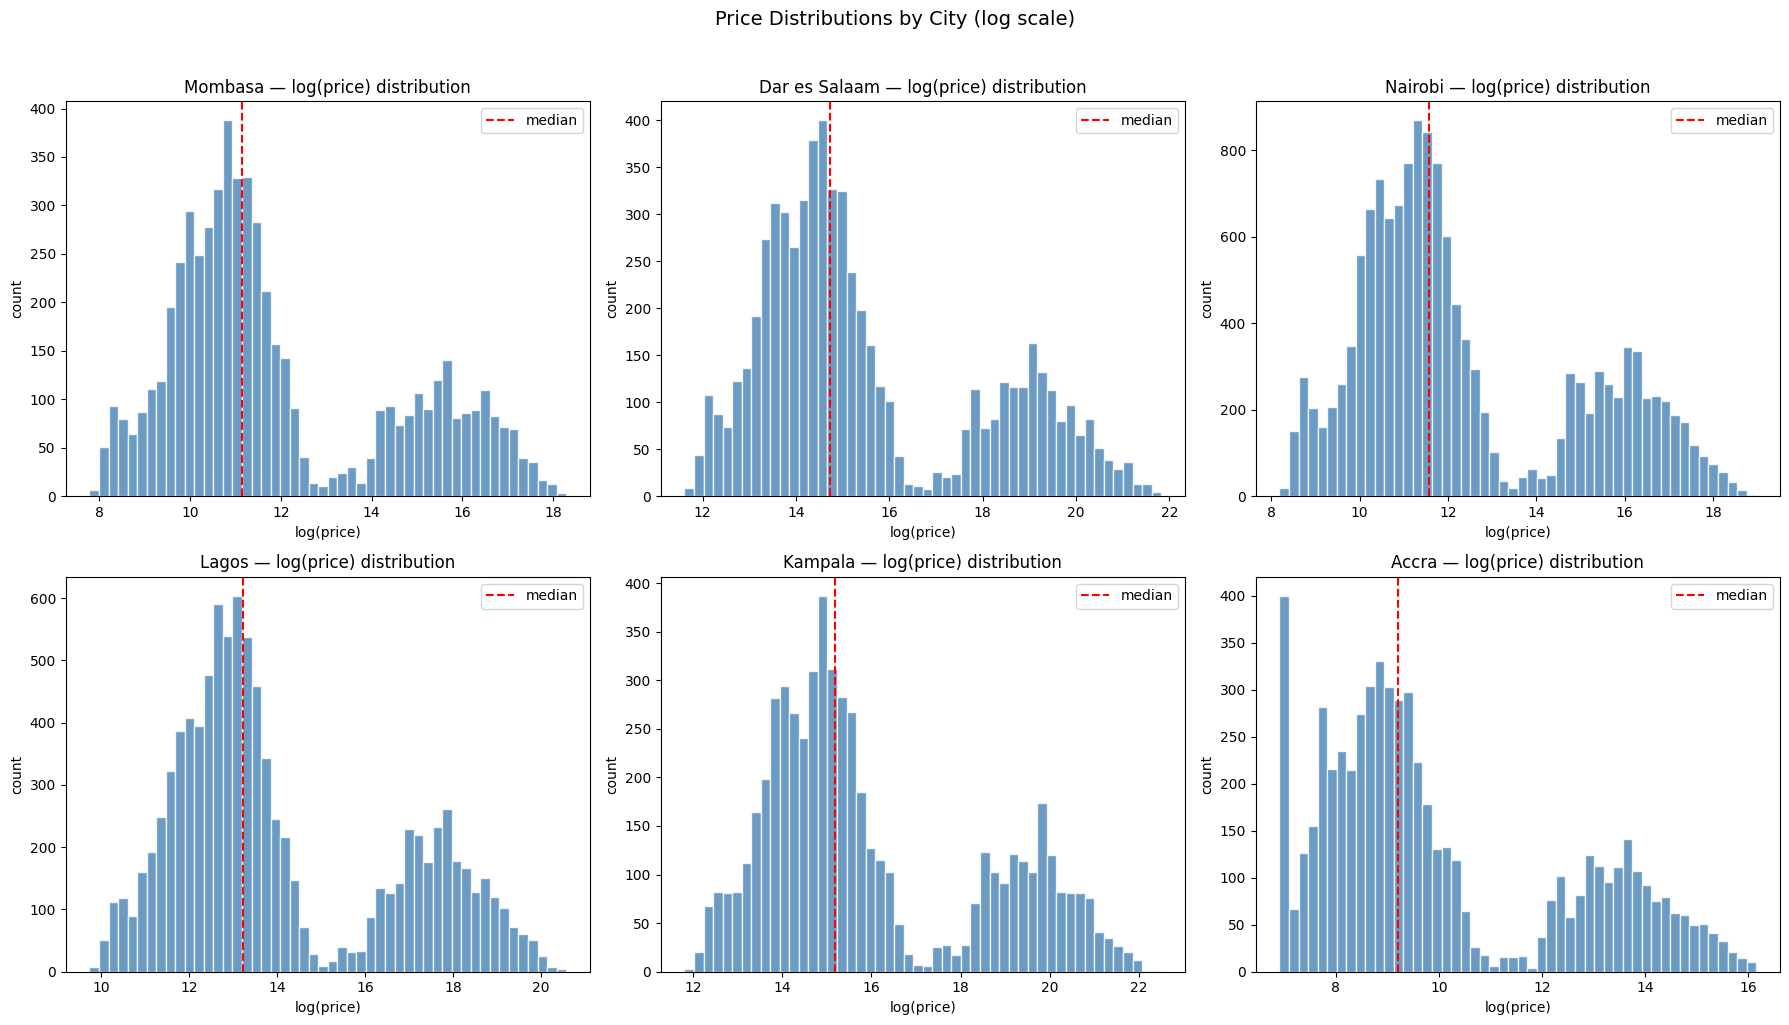

Saved: 01_price_distributions.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
cities = df.city.unique()

for i, city in enumerate(cities):
    city_df = df[(df.city == city) & (df.is_fraud == 0)]
    log_prices = np.log1p(city_df["price"])
    axes[i].hist(log_prices, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(f"{city} — log(price) distribution", fontsize=12)
    axes[i].set_xlabel("log(price)")
    axes[i].set_ylabel("count")
    axes[i].axvline(log_prices.median(), color="red", linestyle="--", label="median")
    axes[i].legend()

plt.suptitle("Price Distributions by City (log scale)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../../ml/reports/01_price_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 01_price_distributions.png")

# **Correlation matrix**

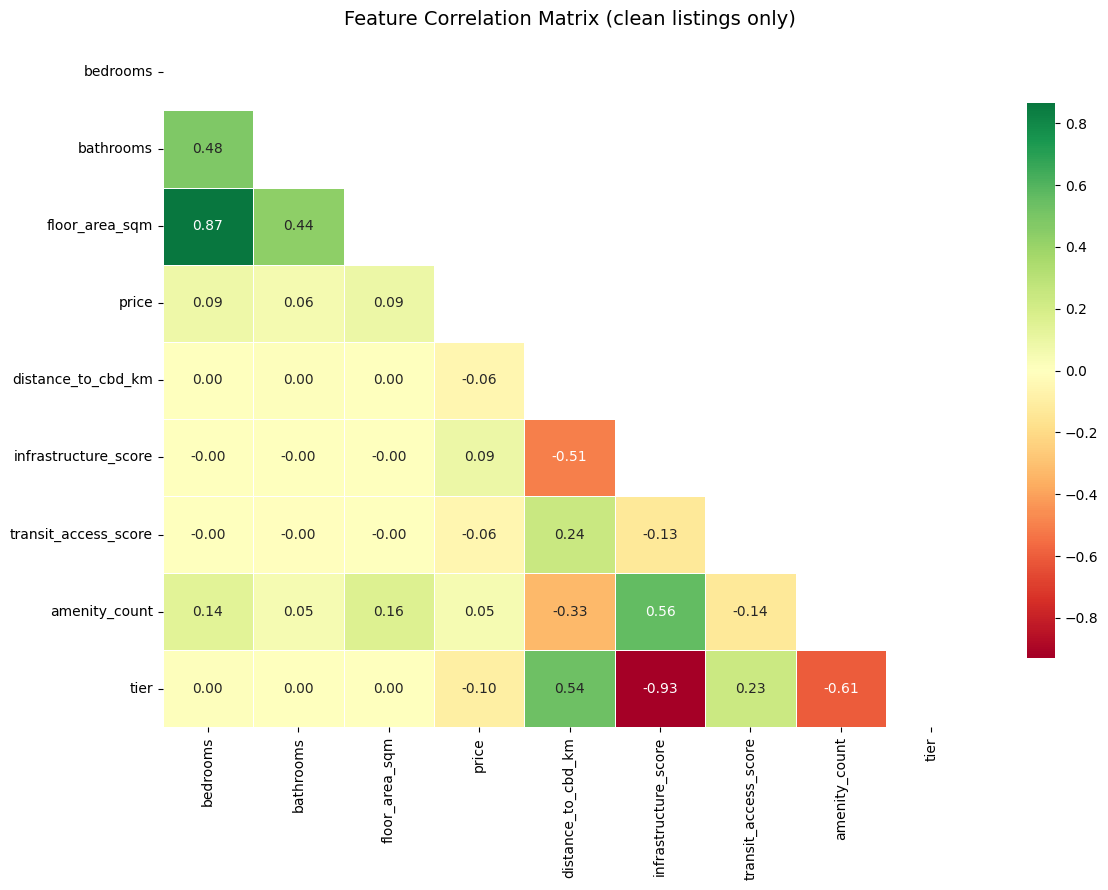

Saved: 01_correlation_matrix.png


In [5]:
numeric_cols = [
    "bedrooms","bathrooms","floor_area_sqm","price",
    "distance_to_cbd_km","infrastructure_score",
    "transit_access_score","amenity_count","tier"
]
clean_df = df[df.is_fraud == 0][numeric_cols].copy()

fig, ax = plt.subplots(figsize=(12, 9))
corr = clean_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, ax=ax,
    linewidths=0.5, cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Matrix (clean listings only)", fontsize=14)
plt.tight_layout()
plt.savefig("../../ml/reports/01_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 01_correlation_matrix.png")

# **Neighbourhood price rankings**

In [6]:
print("=== TOP 10 MOST EXPENSIVE NEIGHBOURHOODS (median monthly rental) ===")
monthly = df[
    (df.is_fraud == 0) &
    (df.price_period == "monthly") &
    (df.property_type == "apartment")
].copy()

nb_median = monthly.groupby(["city","neighbourhood"])["price"].median().reset_index()
nb_median = nb_median.sort_values("price", ascending=False)
print(nb_median.head(15).to_string(index=False))

=== TOP 10 MOST EXPENSIVE NEIGHBOURHOODS (median monthly rental) ===
         city   neighbourhood        price
      Kampala          Kololo 3,743,600.00
      Kampala        Nakasero 3,711,100.00
Dar es Salaam      Oyster Bay 2,544,500.00
Dar es Salaam         Msasani 2,328,050.00
      Kampala          Ntinda 2,014,550.00
      Kampala          Bukoto 1,974,700.00
Dar es Salaam       Kinondoni 1,298,400.00
Dar es Salaam       Mikocheni 1,280,100.00
      Kampala          Naalya 1,034,500.00
      Kampala          Kireka 1,016,200.00
Dar es Salaam          Temeke   679,900.00
Dar es Salaam         Mbagala   665,800.00
        Lagos Victoria Island   474,100.00
        Lagos           Ikoyi   473,200.00
        Lagos           Lekki   458,000.00


# **Fraud vs clean price comparison**

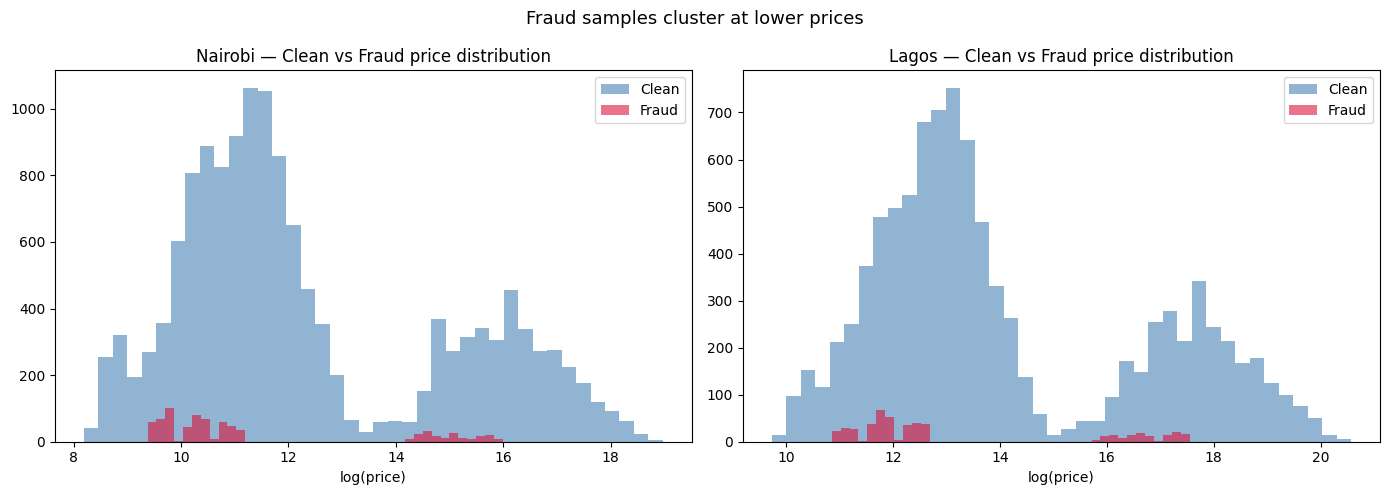

Saved: 01_fraud_vs_clean_prices.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, city in enumerate(["Nairobi", "Lagos"]):
    city_df = df[df.city == city]
    clean  = np.log1p(city_df[city_df.is_fraud==0]["price"])
    fraud  = np.log1p(city_df[city_df.is_fraud==1]["price"])
    axes[i].hist(clean, bins=40, alpha=0.6, label="Clean", color="steelblue")
    axes[i].hist(fraud, bins=40, alpha=0.6, label="Fraud", color="crimson")
    axes[i].set_title(f"{city} — Clean vs Fraud price distribution")
    axes[i].set_xlabel("log(price)")
    axes[i].legend()

plt.suptitle("Fraud samples cluster at lower prices", fontsize=13)
plt.tight_layout()
plt.savefig("../../ml/reports/01_fraud_vs_clean_prices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 01_fraud_vs_clean_prices.png")

# **Seasonal patterns**

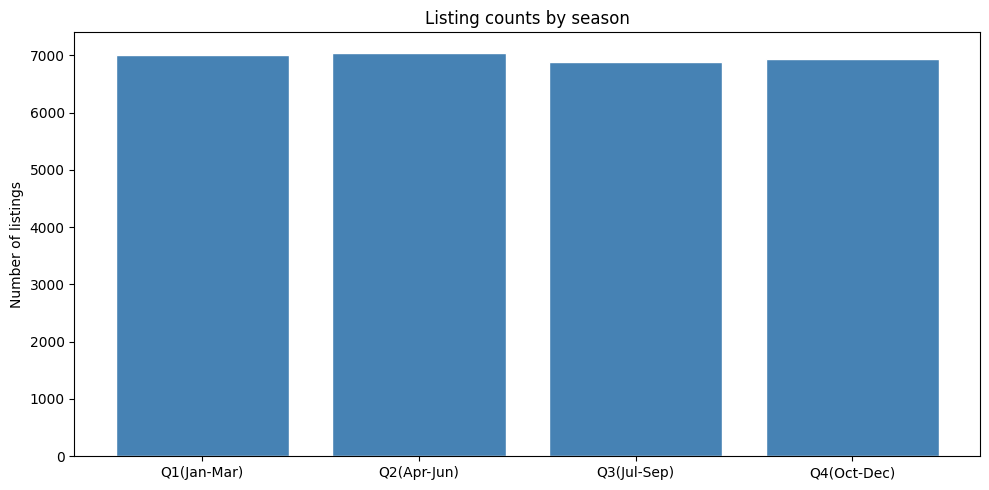

In [8]:
monthly_df = df[(df.is_fraud==0) & (df.price_period=="monthly")].copy()
monthly_df["season"] = monthly_df["listing_month"].apply(
    lambda m: "Q1(Jan-Mar)" if m%12 in [1,2,3] else
              "Q2(Apr-Jun)" if m%12 in [4,5,6] else
              "Q3(Jul-Sep)" if m%12 in [7,8,9] else "Q4(Oct-Dec)"
)

fig, ax = plt.subplots(figsize=(10, 5))
season_counts = monthly_df.groupby("season").size().reset_index(name="count")
ax.bar(season_counts["season"], season_counts["count"], color="steelblue", edgecolor="white")
ax.set_title("Listing counts by season")
ax.set_ylabel("Number of listings")
plt.tight_layout()
plt.savefig("../../ml/reports/01_seasonal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

# **Summary findings**

In [9]:
print("=== EXPLORATION SUMMARY ===")
print(f"""
Key findings:
1. Price distributions are log-normal per city — confirms log-transform for modelling
2. floor_area_sqm has highest correlation with price: {corr['price']['floor_area_sqm']:.2f}
3. infrastructure_score correlation with price:       {corr['price']['infrastructure_score']:.2f}
4. distance_to_cbd_km correlation with price:         {corr['price']['distance_to_cbd_km']:.2f}
5. Fraud samples visibly cluster at lower price ranges — Isolation Forest should separate them
6. No missing values in dataset — clean for modelling
7. Tier variable has strong negative correlation with price: {corr['price']['tier']:.2f}
   (tier 1 = premium = high price, tier 3 = budget = low price)

Ready for feature engineering.
""")

=== EXPLORATION SUMMARY ===

Key findings:
1. Price distributions are log-normal per city — confirms log-transform for modelling
2. floor_area_sqm has highest correlation with price: 0.09
3. infrastructure_score correlation with price:       0.09
4. distance_to_cbd_km correlation with price:         -0.06
5. Fraud samples visibly cluster at lower price ranges — Isolation Forest should separate them
6. No missing values in dataset — clean for modelling
7. Tier variable has strong negative correlation with price: -0.10
   (tier 1 = premium = high price, tier 3 = budget = low price)

Ready for feature engineering.



In [10]:
# Correlation WITHIN a single city only — removes currency noise
nairobi = df[(df.city=="Nairobi") & (df.is_fraud==0)][numeric_cols].copy()
nairobi_corr = nairobi.corr()
print("=== NAIROBI ONLY — price correlations ===")
print(nairobi_corr["price"].sort_values(ascending=False).round(3))

=== NAIROBI ONLY — price correlations ===
price                   1.00
bedrooms                0.18
floor_area_sqm          0.18
infrastructure_score    0.16
bathrooms               0.11
amenity_count           0.09
transit_access_score   -0.04
distance_to_cbd_km     -0.10
tier                   -0.18
Name: price, dtype: float64


In [11]:
print("""
=== CORRECTED EXPLORATION SUMMARY ===

Raw correlations across all cities are weak (0.09) due to mixed currencies.
Per-city correlations (Nairobi) reveal real market signals:

  bedrooms            +0.18  — more bedrooms = higher price
  floor_area_sqm      +0.18  — larger area = higher price  
  infrastructure_score+0.16  — better infra = higher price
  tier                -0.18  — tier 1 premium = highest price
  distance_to_cbd_km  -0.10  — further from CBD = cheaper

Feature engineering strategy confirmed:
  1. Model per currency group OR log-normalise within city
  2. Tier, infrastructure_score, distance_to_cbd are strong predictors
  3. No missing values — dataset is clean
  4. Fraud samples cluster at lower prices — detectable signal

Ready for notebook 02 — feature engineering.
""")


=== CORRECTED EXPLORATION SUMMARY ===

Raw correlations across all cities are weak (0.09) due to mixed currencies.
Per-city correlations (Nairobi) reveal real market signals:

  bedrooms            +0.18  — more bedrooms = higher price
  floor_area_sqm      +0.18  — larger area = higher price  
  infrastructure_score+0.16  — better infra = higher price
  tier                -0.18  — tier 1 premium = highest price
  distance_to_cbd_km  -0.10  — further from CBD = cheaper

Feature engineering strategy confirmed:
  1. Model per currency group OR log-normalise within city
  2. Tier, infrastructure_score, distance_to_cbd are strong predictors
  3. No missing values — dataset is clean
  4. Fraud samples cluster at lower prices — detectable signal

Ready for notebook 02 — feature engineering.

